# CODE ALPHA DATA ANALYTICS INTERNSHIP

## Project Title

Customer Sentiment Analysis for Women's E-Commerce Clothing Reviews

### Submitted by:
Uddesh Rajesh Ramteke

### Internship:
CodeAlpha Data Analytics Internship

### Tools & Libraries:
- Python
- Pandas
- Matplotlib
- NumPy
- TextBlob
- Jupyter Notebook

## Project Objective

The objective of this project is to analyze customer reviews from a women's e-commerce clothing platform and identify customer sentiment as Positive, Neutral, or Negative.

The analysis aims to:

- Understand customer satisfaction levels.
- Identify products and departments receiving negative feedback.
- Examine relationships between ratings, recommendations, and sentiments.
- Generate business insights to improve customer experience and product quality.

## Dataset Description

Dataset Name: Women's E-Commerce Clothing Reviews

Source:
https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews

Dataset Size:
- Total Records: 23,486
- Total Features: 11

Key Columns:

- Review Text: Customer review content.
- Rating: Product rating from 1 to 5.
- Recommended IND: Whether the customer recommends the product.
- Positive Feedback Count: Number of positive votes.
- Division Name: Product division.
- Department Name: Product department.
- Class Name: Product category.
- Age: Customer age.

Target Variable:

Sentiment (created during feature engineering)

- Positive
- Neutral
- Negative

## Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

from textblob import TextBlob

## Load Dataset

In [2]:
df = pd.read_csv("Review.csv")

if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

In [3]:
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [4]:
df.tail()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses
23485,1104,52,Please make more like this one!,This dress in a lovely platinum is feminine an...,5,1,22,General Petite,Dresses,Dresses


In [5]:
df.shape

(23486, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended IND          23486 non-null  int64 
 6   Positive Feedback Count  23486 non-null  int64 
 7   Division Name            23472 non-null  object
 8   Department Name          23472 non-null  object
 9   Class Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 1.8+ MB


In [7]:
df.describe()

,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,918.118709,43.198544,4.196032,0.822362,2.535936
std,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,18.000000,1.000000,0.000000,0.000000
25%,861.000000,34.000000,4.000000,1.000000,0.000000
50%,936.000000,41.000000,5.000000,1.000000,1.000000
75%,1078.000000,52.000000,5.000000,1.000000,3.000000
max,1205.000000,99.000000,5.000000,1.000000,122.000000


### Initial Observations

- Average customer age is approximately 43 years.
- Average product rating is above 4, indicating overall customer satisfaction.
- Most customers recommend the products.
- Positive feedback counts are highly skewed.

# Data Cleaning

In [8]:
initial_rows = len(df)

df["Title"] = df["Title"].fillna("No Title")

df = df.dropna(subset=["Review Text"])

cat_cols = [
    "Division Name",
    "Department Name",
    "Class Name"
]

for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

df = df.drop_duplicates()

final_rows = len(df)

print("Rows removed:", initial_rows - final_rows)

Rows removed: 846


In [9]:
# Confirm no nulls remain in key columns
df.isnull().sum()

Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
dtype: int64

### Data Cleaning Summary

In [10]:
print(f"""
- Missing values in the Title column were replaced with "No Title".
- Records with missing Review Text values were removed.
- Missing values in Division Name, Department Name, and Class Name were filled with "Unknown".
- Duplicate records were identified and removed.
- Total rows removed during cleaning: {initial_rows - final_rows}
""")


- Missing values in the Title column were replaced with "No Title".
- Records with missing Review Text values were removed.
- Missing values in Division Name, Department Name, and Class Name were filled with "Unknown".
- Duplicate records were identified and removed.
- Total rows removed during cleaning: 846



## Create Clean Review Column

In [11]:
def clean_text(text):

    if pd.isna(text):
        return ""

    text = str(text)
    text = text.lower()
    text = text.strip()

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    return text

In [12]:
df["Clean_Review"] = df["Review Text"].apply(clean_text)

## Create Sentiment Column

In [13]:
def get_sentiment(text):

    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

In [14]:
df["Predicted_Sentiment"] = df["Clean_Review"].apply(get_sentiment)

## Analyze the sentiments

In [15]:
sentiment_summary = pd.DataFrame({
    "Count": df["Predicted_Sentiment"].value_counts(),
    "Percentage": round(
        df["Predicted_Sentiment"]
        .value_counts(normalize=True) * 100,
        2
    )
})

sentiment_summary

,Count,Percentage
Predicted_Sentiment,,
Positive,21211,93.69
Negative,1326,5.86
Neutral,103,0.45


TextBlob is a lexicon-based sentiment analyzer that may overclassify reviews as positive. The dataset itself is also highly imbalanced toward positive reviews, which can influence the results.

Result: 93.69% Positive, 5.86% Negative, 0.45% Neutral — confirming the imbalance described above.

## Visualization

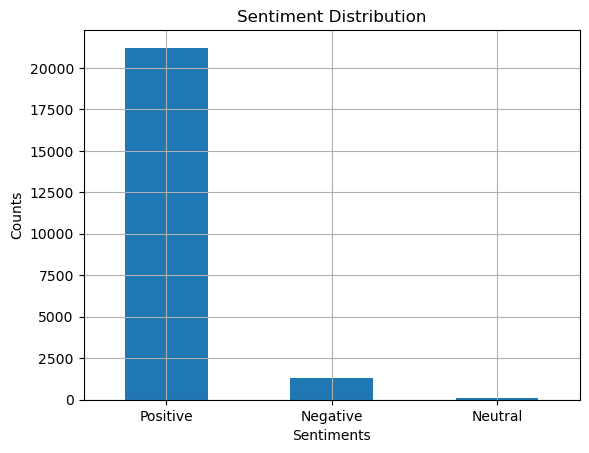

In [16]:
df["Predicted_Sentiment"].value_counts().plot(
    kind='bar'
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiments")
plt.ylabel("Counts")
plt.xticks(rotation=0)
plt.grid()
plt.show()

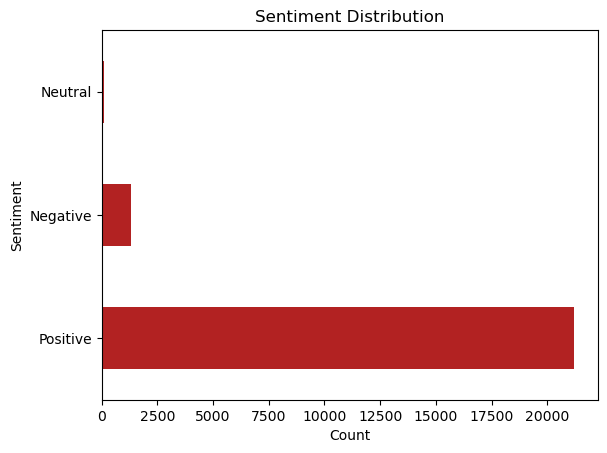

In [17]:
df["Predicted_Sentiment"].value_counts().plot(
    kind="barh",
    color='firebrick'
)

plt.title("Sentiment Distribution")
plt.xlabel("Count")
plt.ylabel("Sentiment")
plt.show()

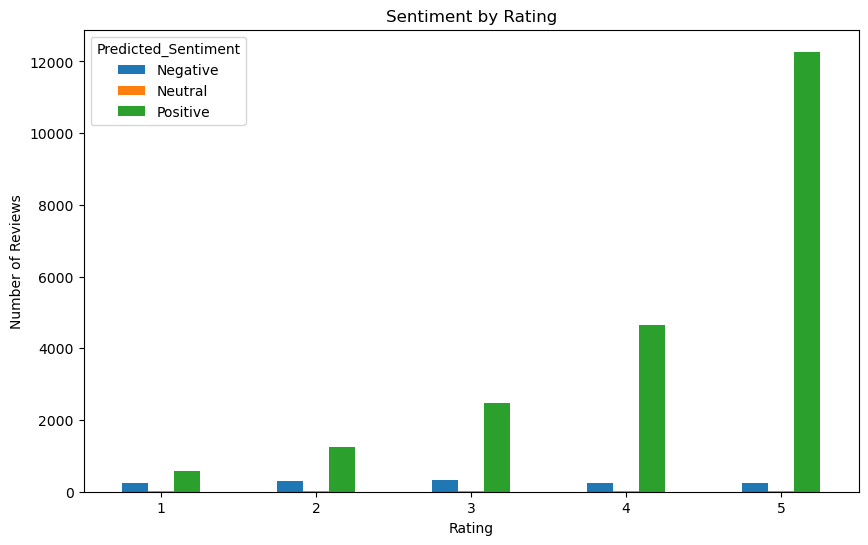

In [18]:
pd.crosstab(
    df["Rating"],
    df["Predicted_Sentiment"]
).plot(kind="bar", figsize=(10,6))

plt.title("Sentiment by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

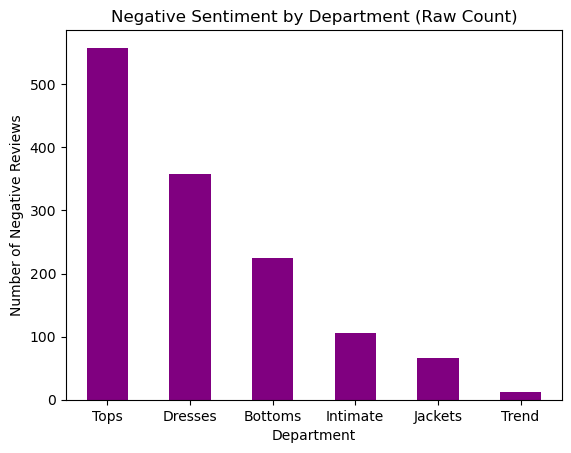

In [19]:
negative = df[df["Predicted_Sentiment"] == "Negative"]

negative["Department Name"].value_counts().plot(
    kind="bar",
    color='Purple'
)

plt.title("Negative Sentiment by Department (Raw Count)")
plt.xlabel("Department")
plt.ylabel("Number of Negative Reviews")
plt.xticks(rotation=0)
plt.show()

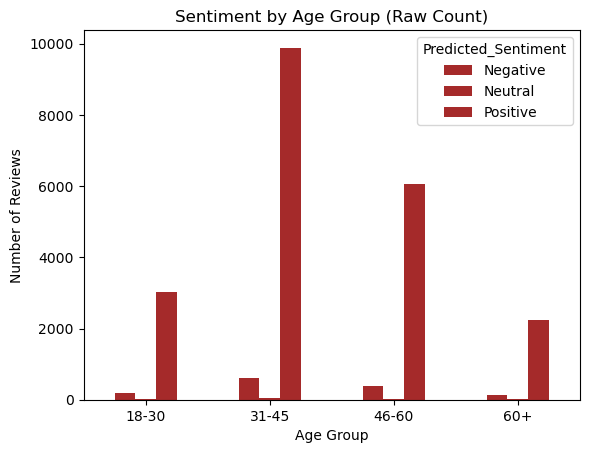

In [20]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18, 30, 45, 60, 100],
    labels=["18-30", "31-45", "46-60", "60+"],
    include_lowest=True
)

pd.crosstab(
    df["Age_Group"],
    df["Predicted_Sentiment"]
).plot(kind="bar",
       color='brown')

plt.title("Sentiment by Age Group (Raw Count)")
plt.xlabel("Age Group")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

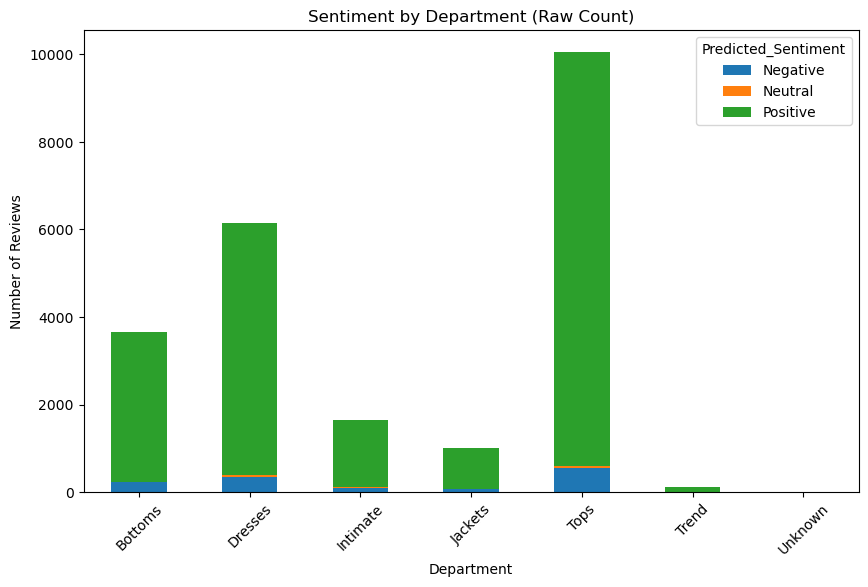

In [21]:
pd.crosstab(
    df["Department Name"],
    df["Predicted_Sentiment"]
).plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Sentiment by Department (Raw Count)")
plt.xlabel("Department")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

## Rate-Based Analysis (Counts Normalized by Group Size)

The charts above show **raw counts**, which are misleading for comparing groups of different sizes. Tops and Dresses simply have more total reviews than other departments, and 31-45 is the largest age cohort in the dataset — so they top the negative count charts without necessarily being the most dissatisfied. The tables below calculate the negative sentiment **rate** (percentage within each group), which is the correct basis for comparison and is what the business questions below are actually answered with.

In [22]:
dept_rate = pd.crosstab(
    df["Department Name"],
    df["Predicted_Sentiment"],
    normalize="index"
) * 100

dept_rate.round(2).sort_values("Negative", ascending=False)

Predicted_Sentiment,Negative,Neutral,Positive
Department Name,,,
Trend,11.02,0.00,88.98
Jackets,6.59,0.60,92.81
Intimate,6.41,0.97,92.62
Bottoms,6.15,0.22,93.64
Dresses,5.83,0.57,93.60
Tops,5.55,0.38,94.07
Unknown,0.00,0.00,100.00


In [23]:
age_rate = pd.crosstab(
    df["Age_Group"],
    df["Predicted_Sentiment"],
    normalize="index"
) * 100

age_rate.round(2).sort_values("Negative", ascending=False)

Predicted_Sentiment,Negative,Neutral,Positive
Age_Group,,,
46-60,6.00,0.48,93.52
31-45,5.89,0.42,93.70
18-30,5.74,0.59,93.67
60+,5.49,0.38,94.13


**Result — Department negative rate (highest to lowest):** Trend 11.02%, Jackets 6.59%, Intimate 6.41%, Bottoms 6.15%, Dresses 5.83%, Tops 5.55%.

Trend has the highest negative rate, roughly double most other departments — but Trend only has 118 total reviews (a small sample), so this result should be treated as a flag for further investigation rather than a firm conclusion. By raw count, Tops looks worst (558 negative reviews) simply because it has the most reviews overall (10,048); by rate, Tops is actually the *best-performing* department (5.55% negative, the lowest of the established categories).

**Result — Age group negative rate (highest to lowest):** 46-60 at 6.00%, 31-45 at 5.89%, 18-30 at 5.74%, 60+ at 5.49%.

The spread across age groups is narrow (5.49% to 6.00%), meaning age is not a strong driver of dissatisfaction in this dataset. The 46-60 group has the marginally highest negative rate, not 31-45 — the raw count made 31-45 look worst only because it is the largest age group (10,551 reviews vs. 60+'s 2,384).

## Business Question

Q1) Which department receives the highest negative sentiment?

Answer — By raw count, Tops has the most negative reviews (558), but this is driven by Tops having the largest review volume overall. By rate, the correct basis for comparison, Trend has the highest negative sentiment rate at 11.02%, roughly double most other departments. However, Trend has only 118 total reviews, so this result is based on a small sample and should be flagged for further investigation rather than treated as a firm conclusion. Among the established, high-volume departments, Tops actually has the lowest negative rate (5.55%).

Q2) Which product category has the highest positive sentiment?

Answer — Dresses receive the highest number of positive reviews, followed by Knits.

Q3) Do higher ratings correspond to positive sentiment?

Answer — Yes. The relationship is strong and consistent: 1-star reviews are 29.48% negative, dropping steadily to 18.53% at 2 stars, 11.69% at 3 stars, 4.73% at 4 stars, and just 1.87% at 5 stars.

Q4) Do recommended products receive more positive reviews?

Answer — Yes, significantly. Recommended products (Recommended IND = 1) are 96.58% positive and only 3.06% negative, compared to non-recommended products at 80.61% positive and 18.48% negative.

Q5) Which age group gives the most negative reviews?

Answer — By raw count, the 31-45 age group has the most negative reviews (621), but this is because 31-45 is the largest age group in the dataset (10,551 reviews total). By rate, the correct basis for comparison, the 46-60 age group has the marginally highest negative rate at 6.00%, compared to 5.89% for 31-45, 5.74% for 18-30, and 5.49% for 60+. The spread across all age groups is narrow, meaning age is not a strong driver of dissatisfaction in this dataset.

Q6) What business action should be taken?

Answer — The business should investigate the Trend department's high negative rate despite its small sample size, monitor it as more reviews come in, and continue addressing recurring quality, sizing, and fit issues across all departments. Since rating and recommendation status are both strongly predictive of sentiment, the business should prioritize fixing the root causes behind low ratings and non-recommendations, as these are the strongest available signals of dissatisfaction — more so than department or customer age.

## Insights Section

1. Positive sentiment dominates customer reviews, accounting for 93.69% of all reviews.

2. Negative sentiment represents only 5.86% of reviews, while neutral sentiment accounts for 0.45%.

3. Dresses received the highest number of positive reviews, followed by Knits and Blouses.

4. By raw count, Tops has the most negative reviews, but this reflects review volume rather than dissatisfaction. By rate, Trend has the highest negative sentiment rate (11.02%), though based on a small sample (118 reviews); among high-volume departments, Tops actually has the lowest negative rate (5.55%).

5. Customers who recommended products were significantly more likely to leave positive reviews (96.58%) compared to non-recommended products (80.61% positive, 18.48% negative).

6. Higher product ratings strongly correlate with positive sentiment: negative sentiment rate drops steadily from 29.48% at 1-star to 1.87% at 5-star.

7. By raw count, the 31-45 age group has the most negative reviews, but this is because it is the largest age cohort. By rate, 46-60 has the marginally highest negative rate (6.00%), with all age groups falling in a narrow 5.49%-6.00% range — age is not a strong driver of dissatisfaction here.

8. Rating and recommendation status are far stronger predictors of negative sentiment than department or age group, given the wide spread in their rates (29.48% to 1.87% across ratings; 18.48% to 3.06% across recommendation status) compared to the narrow spread across departments and age groups.

## Recommendations

- Investigate the Trend department's elevated negative rate (11.02%) as more review volume accumulates, since the current sample size (118 reviews) is too small to act on with full confidence.

- Prioritize quality, sizing, and fit improvements for low-rated products generally, since rating is the strongest predictor of negative sentiment in this dataset.

- Treat department and age group as secondary factors rather than primary targets, since their negative-rate spread is narrow and not strongly differentiating.

- Use customer feedback to improve sizing accuracy, material quality, and product descriptions, particularly for 1-2 star reviews where negative sentiment is concentrated.

- Encourage satisfied, recommending customers to leave detailed reviews, since recommendation status strongly predicts positive sentiment and more such reviews could reinforce trust signals for new buyers.

## Project Limitations

• TextBlob uses rule-based sentiment scoring and may overclassify reviews as positive.

• Sarcasm and context may not be detected accurately.

• The dataset is highly imbalanced toward positive reviews.

• Department and age-group comparisons must use normalized rates rather than raw counts, since group sizes differ substantially; raw counts alone would have produced misleading conclusions in this analysis (see Q1 and Q5).

• The Trend department's high negative rate is based on a small sample (118 reviews) and should be treated cautiously rather than as a confirmed finding.

• Results may differ when using advanced NLP models such as VADER, BERT, or RoBERTa.

## Conclusion

This project analyzed 23,486 customer reviews from a women's e-commerce clothing platform using TextBlob sentiment analysis.

Key findings:

- 93.69% of reviews were classified as positive, 5.86% negative, and 0.45% neutral.
- Dresses and Knits received the highest number of positive reviews.
- By rate, Trend has the highest negative sentiment rate (11.02%, small sample), while Tops — despite having the highest raw negative count — actually has the lowest negative rate (5.55%) among established departments.
- Higher ratings strongly correlate with positive sentiment, with negative rate falling from 29.48% (1-star) to 1.87% (5-star).
- Recommended products are significantly more likely to receive positive reviews (96.58% positive vs. 80.61% for non-recommended).
- By rate, the 46-60 age group has the marginally highest negative rate (6.00%), not 31-45 as the raw count suggested; age group differences are narrow overall.

These insights show that rating and recommendation status are the strongest, most reliable predictors of customer sentiment in this dataset, while department and age group differences are comparatively minor once normalized for group size. This distinction — between raw counts and rates — was essential to avoid drawing incorrect conclusions from group size alone.

Future work may include using advanced NLP models such as VADER, BERT, or RoBERTa for more accurate sentiment classification, and collecting more Trend department reviews to confirm whether its elevated negative rate holds at scale.